## Visual perturbation distribution

In [1]:
import scanpy as sc
import pandas as pd

data_dir = '/home/nas2/biod/yuliyi/data/atlas'
adata = sc.read_h5ad(f"{data_dir}/rna_data/rna_retina_st.h5ad")
retina_ct = pd.read_csv(f"{data_dir}/perturbation_retina/retina_ct.csv", header=None, index_col=0)
adata.obs.Cluster = retina_ct.iloc[:, 0].astype(str)

In [2]:
import glob
import os
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from utils import get_genes_from_gencode
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ==========================================
# 1. Environment and Configuration
# ==========================================
ct = "RGCs"  # Target cell type: RGCs/RPCs
top = 10

# Fetch the Top 10 differentially expressed gene names for the current cell type
gene_name_list = pd.read_csv(f"{data_dir}/perturbation_retina/diff_exp_gene_names.csv")[ct].dropna().values[:top]

# Load global gene annotations to fetch coordinates
gene_range_df = get_genes_from_gencode(os.path.join(data_dir, "gencode.v47.annotation.gtf"))

# Initialize global spot arrays for adaptive aggregation
n_spots = adata.shape[0]
sum_perturbation_array = np.zeros(n_spots)
valid_gene_count_array = np.zeros(n_spots)

# Map all spots to an index-based positioning array
spot_to_idx = {spot: idx for idx, spot in enumerate(adata.obs_names)}

# ==========================================
# 2. Loop and Apply Dual Normalization (Z-score + Min-Max)
# ==========================================
all_gene_final_scores = []

for g_name in gene_name_list:
    gene_info = gene_range_df[gene_range_df['name'] == g_name]
    if gene_info.empty:
        print(f"Skipping {g_name}: not found in gene annotations.")
        continue
    
    gene_chrom = gene_info['chrom'].values[0]
    search_pattern = f"{data_dir}/perturbation_retina/gene_peak_regulation/atac_delta_retina_{ct}_{g_name}_*.h5ad"
    matched_files = glob.glob(search_pattern)

    if not matched_files:
        print(f"Warning: No perturbation file found for gene {g_name}, skipping.")
        continue

    gene_perturb_matrix = sc.read_h5ad(matched_files[0])
    # Slice the matrix and compute mean absolute delta X
    non_zero_means = np.mean(np.abs(gene_perturb_matrix.X), axis=1)

    # Align with global adata, filling unexpressed spots with 0.0
    perturb_series = pd.Series(non_zero_means, index=gene_perturb_matrix.obs_names)
    raw_aligned = perturb_series.reindex(adata.obs_names, fill_value=0.0)

    r_max = raw_aligned.max()
    r_min = raw_aligned.min()
    
    if r_max > r_min:
        minmax_r_scores = (raw_aligned - r_min) / (r_max - r_min)
    else:
        minmax_r_scores = pd.Series(0.0, index=adata.obs_names)

    all_gene_final_scores.append(minmax_r_scores)

# ==========================================
# 3. Calculate Global Mean (Unbiased, Shape-Preserved Aggregation)
# ==========================================
combined_df = pd.concat(all_gene_final_scores, axis=1)

# Average across all 10 optimized genes
adata.obs["TargetGene_perturb_score"] = combined_df.mean(axis=1)

# Set up the categorical grouping labels for dual-panel visualization
adata.obs["Plot_Group"] = adata.obs["Cluster"].astype(str)
adata.obs.loc[adata.obs["Plot_Group"] != ct, 'Plot_Group'] = "Other"

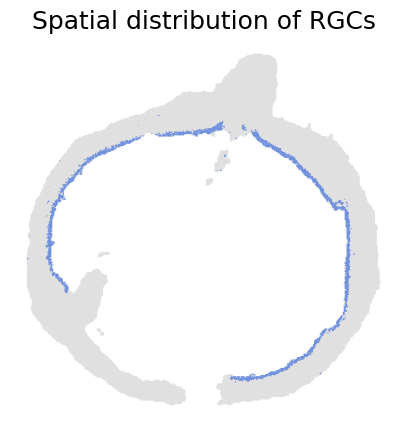

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
ct_color = {"RGCs": "#7091DD", "RPCs": "#66C2A5", "MCs":  "#f85151", "ACs":  "#22b3bd", "BCs":  "#9467bd", "PCs":  "#FC8D62",}
colors = ["#e0e0e0", "#ffffd4", "#fdd0a2", "#e6550d"]
my_cmap = mcolors.LinearSegmentedColormap.from_list("custom_gray_fire", colors)

fig, ax = plt.subplots(figsize=(5, 5))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="Plot_Group",
    title=f"Spatial distribution of {ct}",
    size=6,
    alpha=1.0,
    sort_order=True,  # Ensure high-activity spots are rendered on top
    frameon=False,
    palette={"Other": "#e0e0e0", ct: ct_color[ct]},
    cmap=my_cmap,
    ax=ax,
    show=False,
)
ax.set_title(ax.get_title(), fontsize=18)
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_title(ax.get_title(), fontsize=18)

plt.savefig(f'{data_dir}/perturbation_retina/figs/distribution_observed_{ct}.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot UMAP, spatial distribution of perturbation score

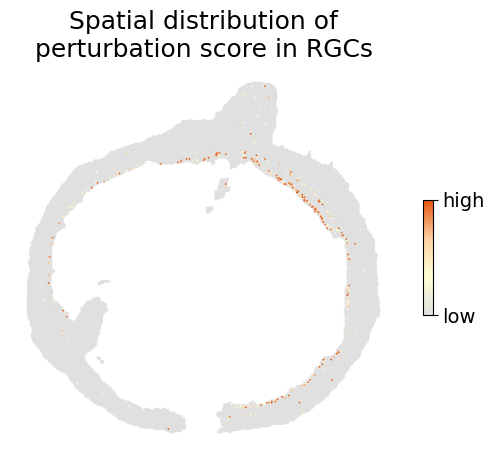

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
ct_color = {"RGCs": "#7091DD", "RPCs": "#66C2A5", "MCs":  "#f85151", "ACs":  "#22b3bd", "BCs":  "#9467bd", "PCs":  "#FC8D62",}
colors = ["#e0e0e0", "#ffffd4", "#fdd0a2", "#e6550d"]
my_cmap = mcolors.LinearSegmentedColormap.from_list("custom_gray_fire", colors)

# Dynamically determine robust vmax via 98th percentile to cut off extreme noise outliers
vmin_visual = np.percentile(adata.obs["TargetGene_perturb_score"], 98)
vmax_dynamic = np.percentile(
    adata.obs["TargetGene_perturb_score"][adata.obs["TargetGene_perturb_score"] > 0], 99
)

fig, ax = plt.subplots(figsize=(5, 5))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="TargetGene_perturb_score",
    title=f"Spatial distribution of\nperturbation score in {ct}",
    size=6,
    alpha=1.0,
    sort_order=True,  # Ensure high-activity spots are rendered on top
    frameon=False,
    cmap=my_cmap,
    vmin=vmin_visual,
    vmax=vmax_dynamic,  # Swapped rigid vmax with statistically robust dynamic threshold
    wspace=0.01,
    colorbar_loc=None,
    ax=ax,
    show=False,
)

ax.set_title(ax.get_title(), fontsize=18)

# ---- Colorbar Position and Formatting Polish ----
fig = plt.gcf()
fig.set_layout_engine("none")
pos_right = ax.get_position()
cbar_width = 0.02
cbar_height_ratio = 0.3
space_between = 0.05

left = pos_right.x1 + space_between
width = cbar_width
height = pos_right.height * cbar_height_ratio
bottom = pos_right.y0 + (pos_right.height - height) / 2

cax = fig.add_axes([left, bottom, width, height])
cbar = fig.colorbar(ax.collections[0], cax=cax)
cbar.set_ticks([vmin_visual, vmax_dynamic])
cbar.set_ticklabels(["low", "high"], fontsize=14)
plt.savefig(f'{data_dir}/perturbation_retina/figs/distribution_{ct}.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot violin, differential perturbation score

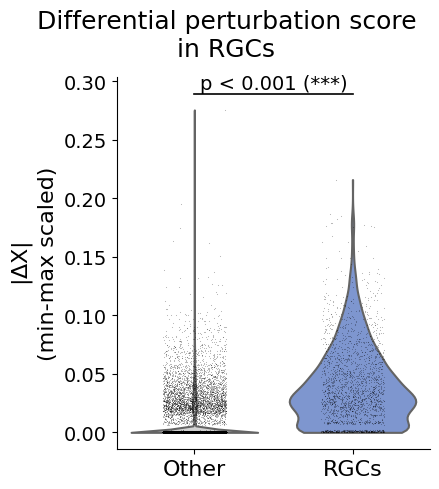

In [ ]:
import seaborn as sns
plt.figure(figsize=(4.5, 5))

ax = sns.violinplot(
    data=adata.obs,
    x='Plot_Group',
    y='TargetGene_perturb_score',
    order=['Other', ct],
    palette={'Other': '#d3d3d3', ct: ct_color[ct]},
    inner=None,
    linewidth=1.5,
    cut=0
)

sns.stripplot(
    data=adata.obs,
    x='Plot_Group',
    y='TargetGene_perturb_score',
    order=['Other', ct],
    color='black',
    size=0.8,
    alpha=0.3, 
    jitter=0.2,
    ax=ax
)

x1, x2 = 0, 1
y, h = adata.obs['TargetGene_perturb_score'].max() * 1.05, 0.0002
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
plt.text((x1+x2)*0.5, y+h*1.5, "p < 0.001 (***)", ha='center', va='bottom', color='black', fontsize=14)

plt.xlabel(None)
plt.xticks(fontsize=16)
plt.yticks(fontsize=14)
plt.ylabel('|$\\Delta$X|\n(min-max scaled)', fontsize=16)
sns.despine()
plt.title(f'Differential perturbation score\nin {ct}', fontsize=18, x=0.35, ha='center', pad=15)
plt.tight_layout()
plt.savefig(f'{data_dir}/perturbation_retina/figs/violin_{ct}.png', dpi=300)
plt.show()

In [6]:
from scipy.stats import ranksums
rgc_scores = adata.obs[adata.obs['Cluster'] == ct]['TargetGene_perturb_score']
other_scores = adata.obs[adata.obs['Cluster'] != ct]['TargetGene_perturb_score']

stat, p_val = ranksums(rgc_scores, other_scores)
print(f"Wilcoxon p-value: {p_val}")

Wilcoxon p-value: 0.0
